In [1]:
import pandas as pd
from tabulate import tabulate
from utils import PREPROCESSING_CONFIGS, VECTORIZER_CONFIGS, ALGORITHM_CONFIGS
import matplotlib.pyplot as plt
import seaborn as sns
from utils import TextPreprocessor, Word2VecVectorizer
from utils import RAW_DATA_DIR, OUTPUT_DATA_DIR
from wordcloud import WordCloud
import numpy as np

df = pd.read_csv(RAW_DATA_DIR / "spam_assassin.csv", nrows=5)

# Porównanie algorytmów

W ramach serii eksperymentów porównane zostały algorytmy:
- MultinomialNB
    - alpha: wygładzanie Laplace: większe alpha moze zmniejszyc ryzyko nadmiernego dopasowania
- SVM
    - C: współczynnik regularyzacji(szerokość marginesu)
    - jądro liniowe; RBF - nieliniowe granice
- Random Forest 
    - n_estimators: liczba drzew w lesie; lepsza stabilność i dokładność
    - max_depth: maksymalna głębokość drzewa; mniejsza głębkość zmniejsza przeuczenie
    - max_features: % cech losowych przy podziale węzła
    - class_weight: wpływ czy balansować rozkład klas
- XGBoost: zespół drzew budowany sekwencyjnie na podstawie wzmocnienia gradientowego róznicy predykcji i składników regularyzacji
    - max_depth: maksymalna głębokość drzewa
    - min_child_weight: minimalna suma wazonych obserwacji w liściu
    - learning_rate: skalowanie wkładu nowego drzewa
    - subsample: procent przykładów losowany do budowy drzewa
    - colsample_bytree: procent cech losowany do kazdej struktury drzewa

In [2]:
for name, config in ALGORITHM_CONFIGS.items():
    print(f"Model: {name}")

    param_data = []
    for param, values in config["param_grid"].items():
        param_clean = param.replace("model__", "")
        param_data.append([param_clean, values])

    print(
        tabulate(param_data, headers=["Parameter", "Values"], tablefmt="simple"),
        end="\n\n",
    )

Model: MultinomialNB
Parameter    Values
-----------  -------------------------
alpha        [0.1, 0.5, 1.0, 2.0, 5.0]

Model: SVM_Linear
Parameter    Values
-----------  -----------------------
C            [0.1, 1.0, 10.0, 100.0]

Model: SVM_RBF
Parameter    Values
-----------  ------------------------------
C            [0.1, 1.0, 10.0]
gamma        ['scale', 'auto', 0.001, 0.01]

Model: RandomForest
Parameter     Values
------------  ------------------
n_estimators  [100, 300]
max_depth     [None, 20]
max_features  ['sqrt']
class_weight  [None, 'balanced']

Model: XGBoost
Parameter         Values
----------------  -----------
max_depth         [4, 6]
min_child_weight  [1, 4]
learning_rate     [0.05, 0.1]
subsample         [0.85]
colsample_bytree  [0.85]



## Konfiguracja eskperymentów

W ramach eksperymentów uzyto preprocessingu: `{'lowercase': True, 'remove_punctuation': True, 'remove_numbers': True, 'remove_stopwords': True, 'stemming': False}` i vectoryzacji TF-IDF bigram

Dla kazdego algorytmu przeprowadzono przegląd siatki hiperparametrów i dla wyłonionych najlepszych parametrów wykonano trening, walidację krzyzową i ewaluację.

## Wyniki

In [3]:
preprocessing_res = pd.read_csv(
    OUTPUT_DATA_DIR / "experiments" / "algorithm_comparison_results.csv"
)

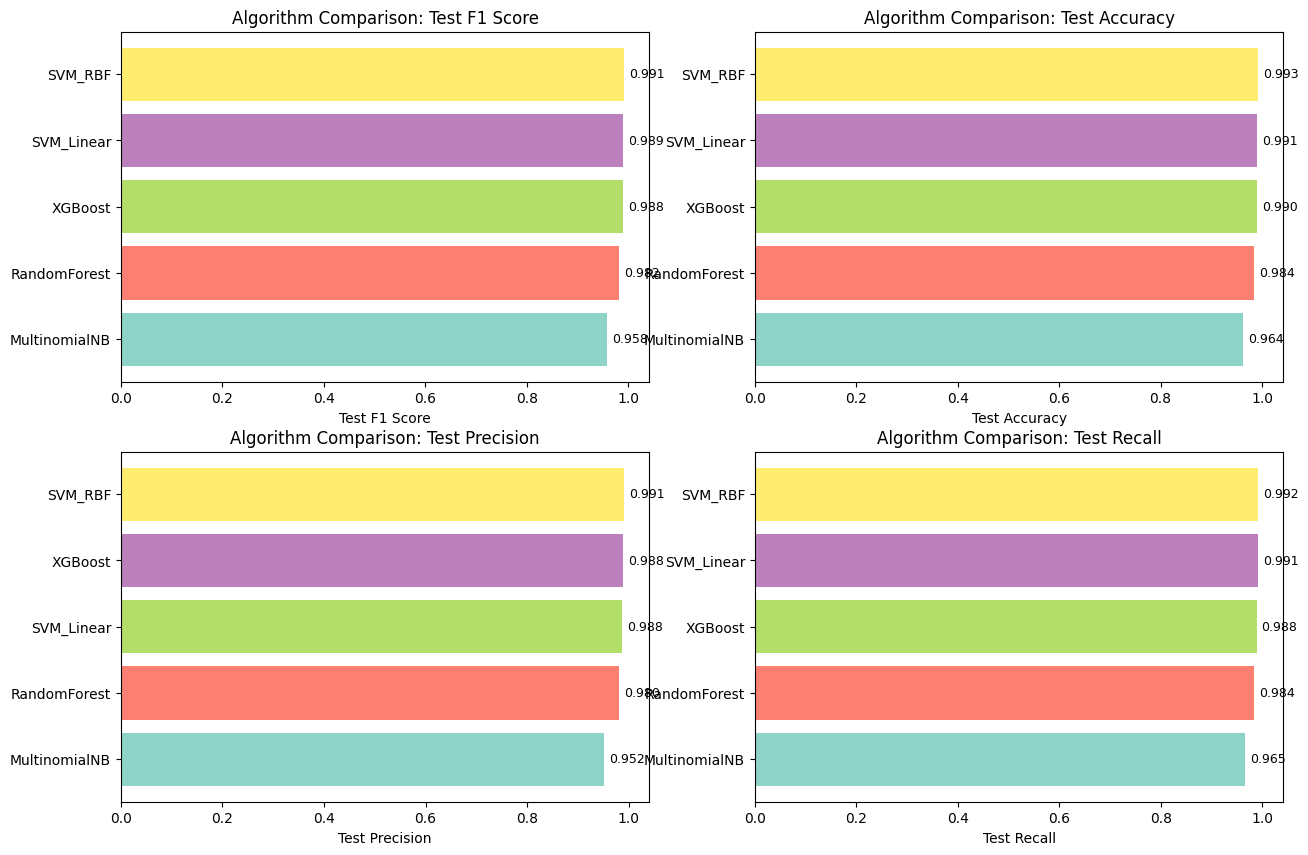

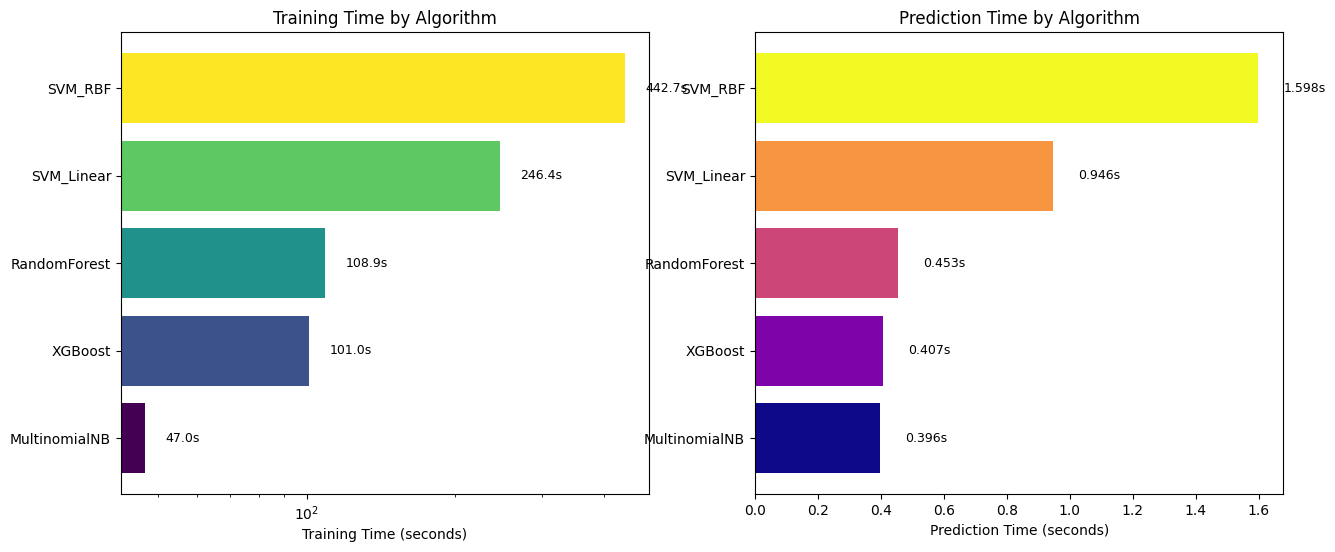

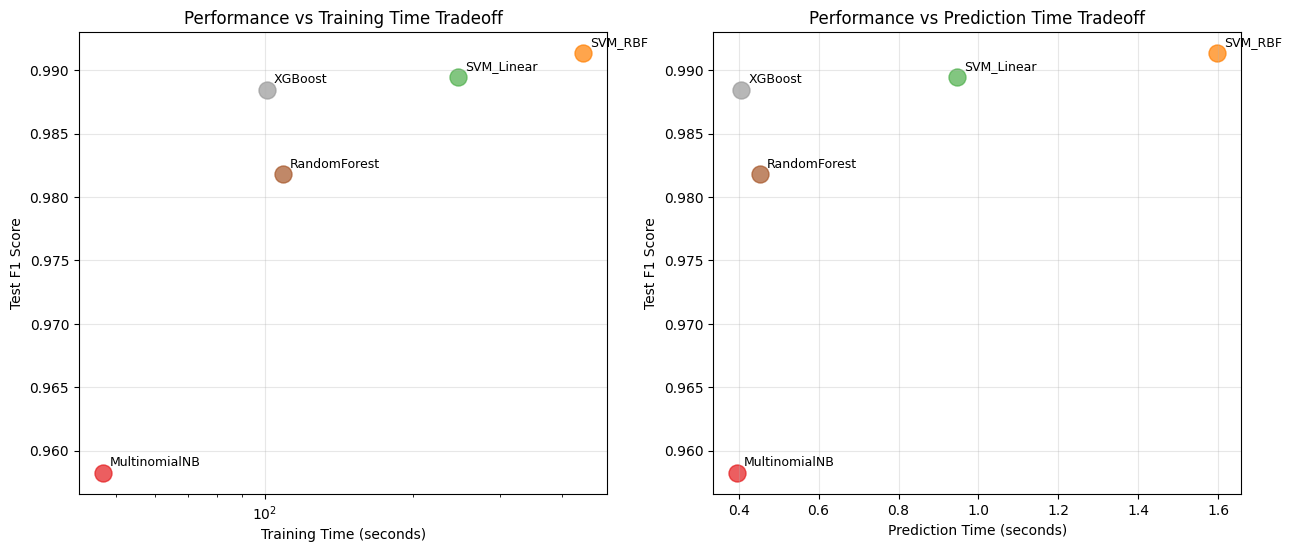

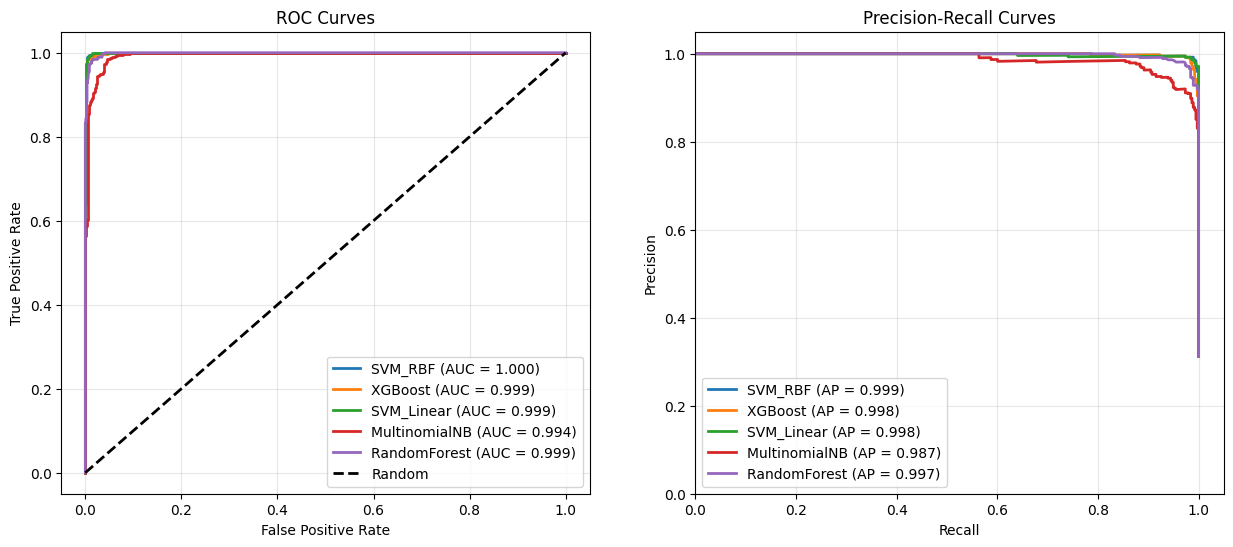

In [4]:
def create_performance_comparison(df):
    """Compare algorithms across different metrics"""
    metrics = [
        "test_f1_macro",
        "test_accuracy",
        "test_precision_macro",
        "test_recall_macro",
    ]
    metric_names = ["F1 Score", "Accuracy", "Precision", "Recall"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax = axes[i]

        # Sort by performance for better visualization
        df_sorted = df.sort_values(metric, ascending=True)

        bars = ax.barh(
            range(len(df_sorted)),
            df_sorted[metric],
            color=plt.cm.Set3(np.linspace(0, 1, len(df_sorted))),
        )

        ax.set_yticks(range(len(df_sorted)))
        ax.set_yticklabels(df_sorted["model"])
        ax.set_xlabel(f"Test {name}")
        ax.set_title(f"Algorithm Comparison: Test {name}")

        # Add value labels on bars
        for j, (bar, value) in enumerate(zip(bars, df_sorted[metric])):
            ax.text(
                value + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va="center",
                fontsize=9,
            )


def create_training_time_analysis(df):
    """Analyze training and prediction times"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Training time comparison
    df_sorted = df.sort_values("training_time_best", ascending=True)
    bars1 = ax1.barh(
        range(len(df_sorted)),
        df_sorted["training_time_best"],
        color=plt.cm.viridis(np.linspace(0, 1, len(df_sorted))),
    )

    ax1.set_yticks(range(len(df_sorted)))
    ax1.set_yticklabels(df_sorted["model"])
    ax1.set_xlabel("Training Time (seconds)")
    ax1.set_title("Training Time by Algorithm")
    ax1.set_xscale("log")  # Log scale for better visualization

    # Add value labels
    for bar, value in zip(bars1, df_sorted["training_time_best"]):
        ax1.text(
            value * 1.1,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}s",
            va="center",
            fontsize=9,
        )

    # Prediction time comparison
    df_sorted2 = df.sort_values("prediction_time", ascending=True)
    bars2 = ax2.barh(
        range(len(df_sorted2)),
        df_sorted2["prediction_time"],
        color=plt.cm.plasma(np.linspace(0, 1, len(df_sorted2))),
    )

    ax2.set_yticks(range(len(df_sorted2)))
    ax2.set_yticklabels(df_sorted2["model"])
    ax2.set_xlabel("Prediction Time (seconds)")
    ax2.set_title("Prediction Time by Algorithm")

    # Add value labels
    for bar, value in zip(bars2, df_sorted2["prediction_time"]):
        ax2.text(
            value + max(df_sorted2["prediction_time"]) * 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}s",
            va="center",
            fontsize=9,
        )


def create_performance_vs_time_tradeoff(df):
    """Show performance vs time tradeoffs"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    colors = plt.cm.Set1(np.linspace(0, 1, len(df)))

    # F1 Score vs Training Time
    for i, (_, row) in enumerate(df.iterrows()):
        ax1.scatter(
            row["training_time_best"],
            row["test_f1_macro"],
            color=colors[i],
            s=150,
            alpha=0.7,
            label=row["model"],
        )
        ax1.annotate(
            row["model"],
            (row["training_time_best"], row["test_f1_macro"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    ax1.set_xlabel("Training Time (seconds)")
    ax1.set_ylabel("Test F1 Score")
    ax1.set_title("Performance vs Training Time Tradeoff")
    ax1.set_xscale("log")
    ax1.grid(True, alpha=0.3)

    # F1 Score vs Prediction Time
    for i, (_, row) in enumerate(df.iterrows()):
        ax2.scatter(
            row["prediction_time"],
            row["test_f1_macro"],
            color=colors[i],
            s=150,
            alpha=0.7,
            label=row["model"],
        )
        ax2.annotate(
            row["model"],
            (row["prediction_time"], row["test_f1_macro"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    ax2.set_xlabel("Prediction Time (seconds)")
    ax2.set_ylabel("Test F1 Score")
    ax2.set_title("Performance vs Prediction Time Tradeoff")
    ax2.grid(True, alpha=0.3)


def plot_curves():
    data_dir = OUTPUT_DATA_DIR / "curve_data"
    roc_df = pd.read_csv(data_dir / "roc_data.csv")
    pr_df = pd.read_csv(data_dir / "pr_data.csv")
    metrics_df = pd.read_csv(data_dir / "metrics_data.csv")

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ROC curves
    for model in roc_df["model"].unique():
        model_data = roc_df[roc_df["model"] == model]
        auc_score = metrics_df[metrics_df["model"] == model]["roc_auc"].iloc[0]
        ax1.plot(
            model_data["fpr"],
            model_data["tpr"],
            label=f"{model} (AUC = {auc_score:.3f})",
            linewidth=2,
        )

    ax1.plot([0, 1], [0, 1], "k--", linewidth=2, label="Random")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC Curves")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # PR curves
    for model in pr_df["model"].unique():
        model_data = pr_df[pr_df["model"] == model]
        ap_score = metrics_df[metrics_df["model"] == model]["pr_auc"].iloc[0]
        ax2.plot(
            model_data["recall"],
            model_data["precision"],
            label=f"{model} (AP = {ap_score:.3f})",
            linewidth=2,
        )

    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-Recall Curves")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    ax2.set_xlim([0, 1.05])


create_performance_comparison(preprocessing_res)
create_training_time_analysis(preprocessing_res)
create_performance_vs_time_tradeoff(preprocessing_res)
plot_curves()

## Porównanie ze względu na kategorie

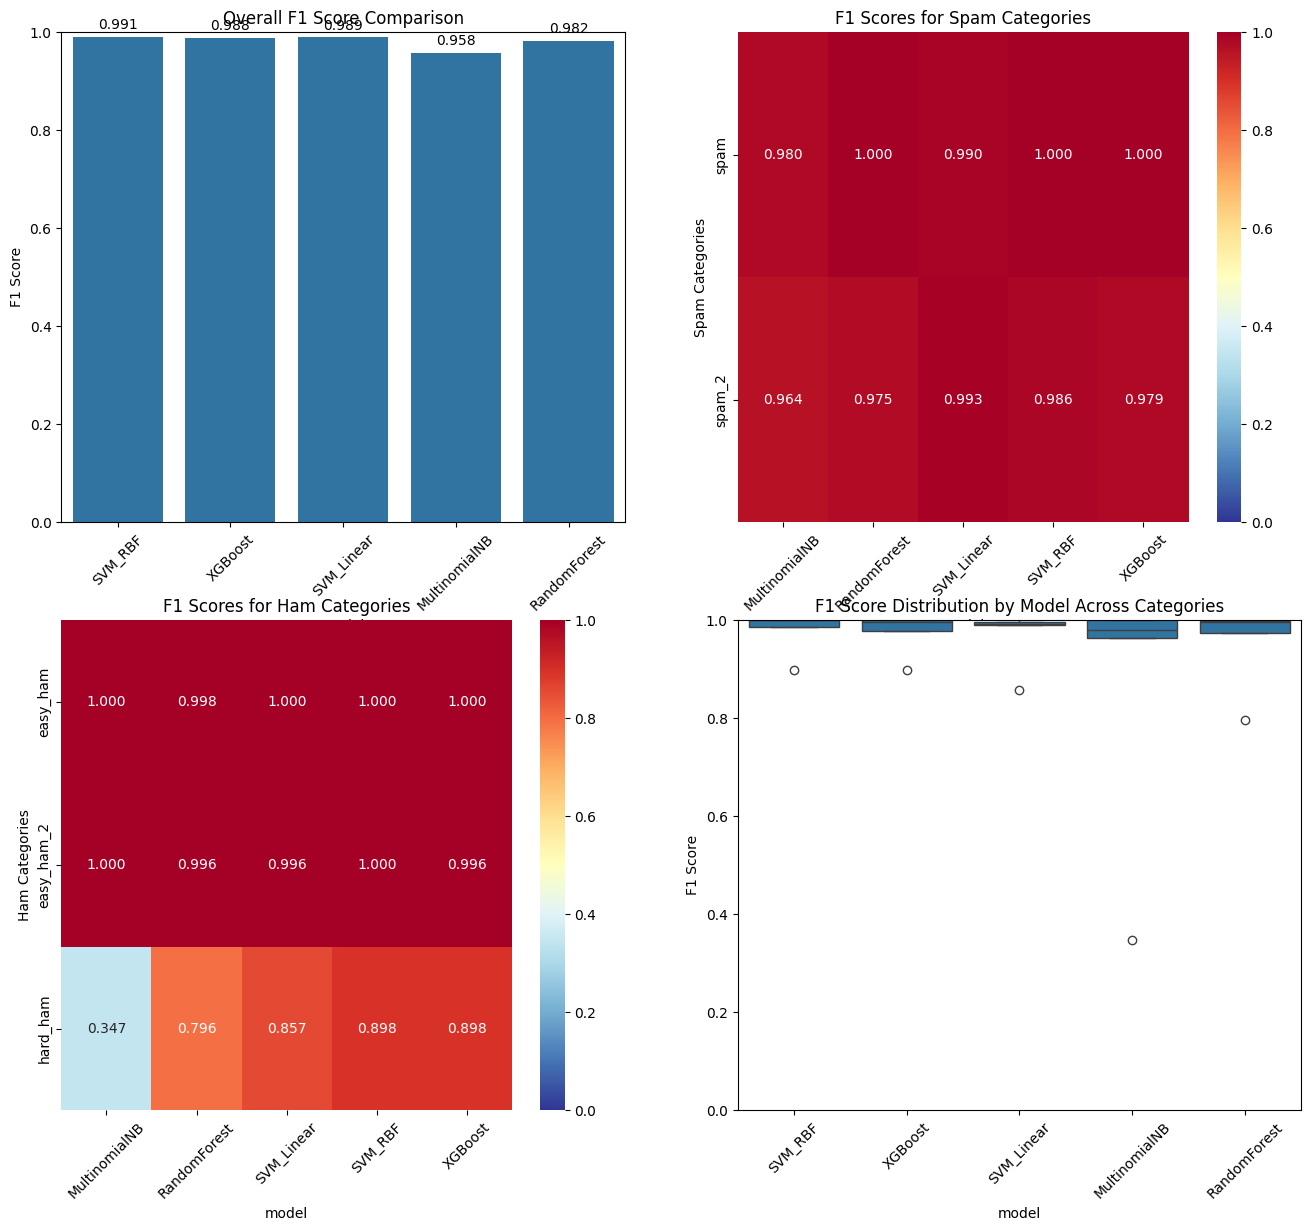

In [5]:
def create_category_comparison_plot(results_df):
    """Create visualization comparing F1 scores by category"""
    # Separate spam and ham categories
    spam_categories = results_df[
        results_df["category"].str.contains("spam", case=False, na=False)
    ]
    ham_categories = results_df[
        results_df["category"].str.contains("ham", case=False, na=False)
    ]
    overall_results = results_df[results_df["category"] == "Overall"]

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # 1. Overall comparison
    if not overall_results.empty:
        sns.barplot(data=overall_results, x="model", y="f1_score", ax=axes[0, 0])
        axes[0, 0].set_title("Overall F1 Score Comparison")
        axes[0, 0].set_ylabel("F1 Score")
        axes[0, 0].tick_params(axis="x", rotation=45)
        axes[0, 0].set_ylim(0, 1)

        # Add value labels on bars
        for i, bar in enumerate(axes[0, 0].patches):
            height = bar.get_height()
            axes[0, 0].text(
                bar.get_x() + bar.get_width() / 2.0,
                height + 0.01,
                f"{height:.3f}",
                ha="center",
                va="bottom",
            )

    # 2. Spam categories
    if not spam_categories.empty:
        pivot_spam = spam_categories.pivot(
            index="category", columns="model", values="f1_score"
        )
        sns.heatmap(
            pivot_spam,
            annot=True,
            fmt=".3f",
            cmap="RdYlBu_r",
            ax=axes[0, 1],
            vmin=0,
            vmax=1,
        )
        axes[0, 1].set_title("F1 Scores for Spam Categories")
        axes[0, 1].set_ylabel("Spam Categories")
        axes[0, 1].tick_params(axis="x", rotation=45)

    # 3. Ham categories
    if not ham_categories.empty:
        pivot_ham = ham_categories.pivot(
            index="category", columns="model", values="f1_score"
        )
        sns.heatmap(
            pivot_ham,
            annot=True,
            fmt=".3f",
            cmap="RdYlBu_r",
            ax=axes[1, 0],
            vmin=0,
            vmax=1,
        )
        axes[1, 0].set_title("F1 Scores for Ham Categories")
        axes[1, 0].set_ylabel("Ham Categories")
        axes[1, 0].tick_params(axis="x", rotation=45)

    # 4. Category comparison by model
    category_results = results_df[results_df["category"] != "Overall"]
    if not category_results.empty:
        sns.boxplot(data=category_results, x="model", y="f1_score", ax=axes[1, 1])
        axes[1, 1].set_title("F1 Score Distribution by Model Across Categories")
        axes[1, 1].set_ylabel("F1 Score")
        axes[1, 1].tick_params(axis="x", rotation=45)
        axes[1, 1].set_ylim(0, 1)


by_cat_df = pd.read_csv(
    OUTPUT_DATA_DIR / "experiments" / "category_performance_results.csv"
)
create_category_comparison_plot(by_cat_df)